This notebook compares Ferrari (RACE) and S&P 500 returns from 2020–2026 across three sections: return analysis, correlation, and linear regression (beta/alpha/R²)

The project is divided into 3 sections:

1- Data loading and cleaning: I download the data, see that it makes sense calculate total and annualized returns

2- Return analysis and correlation

3- Linear regression analysis to determine the correlation between ferrari and the S&P 500

SECTION 1: Data loading and cleaning

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from scipy import stats

#------- SHORT COMMENT ON LIBRARY CHOICE ---------------------------------
#I added plotly because it allowed me to check precise values on the graph
#I still used Matplotlib to illustrate linear regression as it is simpler
#-------------------------------------------------------------------------

#I create the dataframes of the companies between January 1st 2020 and Jan 1st 2026:
data = yf.download(["RACE", "^GSPC"], start = "2020-01-01", end = "2026-01-01")


#Here I printed various statistical indicators and checked if the dataframe was not flawed in some way
print(data.describe())
print(data)
print(data.shape)
print(data.columns)


#Here I print the first and last closing valeus:
print(data["Close", "RACE"].iloc[0])
print(data["Close", "RACE"].iloc[-1])
print(data["Close", "^GSPC"].iloc[0])
print(data["Close", "^GSPC"].iloc[-1])


#After double checking that these values look good we calculate the total return:
race_tr = (data["Close", "RACE"].iloc[-1] / data["Close", "RACE"].iloc[0]) - 1
print(race_tr)
#we see that over the analysed time period Ferrari stock had a total retun of 128.43%

# Now we calculate the S&P 500's total return over that same period of time:
sp500_tr = (data["Close", "^GSPC"].iloc[-1] / data["Close", "^GSPC"].iloc[0]) - 1
print(sp500_tr)
# The S&P 500 over the analysed time period had a total return of 110.12%

#Now i will calculate the annualized return over the 6 year span:

race_ar = (1 + race_tr) ** (1 / 6) - 1
sp500_ar = (1 + sp500_tr) ** (1 / 6) - 1
print(race_ar)
print(sp500_ar)

#Here we notice the the annualized retuns for ferrari are 14.76% while the S&P 500 had a 13.17% annualized return

#Now I do the following
#1) create a new column for cumulative return for the 2 Stocks
#2) plot the two cumulative returns and compare

# 1) cumulative returns column
data["CR", "RACE"] = data["Close"]["RACE"] / data["Close"]["RACE"].iloc[0] - 1
data["CR", "^GSPC"] = data["Close"]["^GSPC"] / data["Close"]["^GSPC"].iloc[0] - 1

# 2) plot the cumulative retuns with plotly express:
fig = px.line(data["CR"].reset_index(), x='Date', y=["RACE", "^GSPC"], title='Cumulative return: Ferrari vs S&P500')
fig.show()

[*********************100%***********************]  2 of 2 completed


Price         Close                      High                       Low  \
Ticker         RACE        ^GSPC         RACE        ^GSPC         RACE   
count   1508.000000  1508.000000  1508.000000  1508.000000  1508.000000   
mean     287.955883  4584.086153   290.291032  4609.688983   285.615499   
std      110.573116  1027.985477   111.196917  1027.963307   109.862244   
min      122.738922  2237.399902   128.044452  2300.729980   121.229833   
25%      195.352142  3907.819946   196.842576  3931.227478   193.519805   
50%      248.628441  4381.074951   250.823113  4410.659912   246.989745   
75%      405.418762  5355.719849   408.680820  5375.297607   402.170895   
max      511.743958  6932.049805   513.177366  6945.770020   508.956122   

Price                       Open                     Volume                
Ticker        ^GSPC         RACE        ^GSPC          RACE         ^GSPC  
count   1508.000000  1508.000000  1508.000000  1.508000e+03  1.508000e+03  
mean    4554.929632  

Graph analysis:
During the first 3 years the return of the two indeces were similar. We can also notice how both were affected by specific geopolitical events. For example the outbreack of covid 19 in 2020 and Trump's announcement of tariffs in 2025.

We can notice in the graph the ferrari's Cumulative return suddently plummets
Obviously something must have happened in that period therefore I decided to research on the internet the reasons related to this drop.
I found out that the drop dates to October 9th 2025, when ferrari held its Capital Markets day presentation.
The stock plummeted down from a value of aprox $500 to $400. This is because investors were disappointed by the changing declared financial forecast.
Specifically investors were disappointed by the following:

1) the 5% target growth rate is a stepdown compared to the double digited growth we saw before
2) the company declared to scale back on EV ambition

Summary for section 1:
- The data frame did not need any cleaning, statistical data is valid
- Ferrari's total and annualized returns are larger than the S&P 500 between January 2021 and January 2026


SECTION 2:
Here I calculate the daily excess return of ferrari stock and then comparing it to the S&P500 and then checking if there is any correlation between the two

In [ ]:

d_returns = data["Close"].pct_change().dropna()
d_returns["excess"] = d_returns["RACE"] - d_returns["^GSPC"]

fig0 = px.line(d_returns.reset_index(), x='Date', y="excess", title='Daily Excess Return: Ferrari vs S&P500')
fig0.show()
#Since the line is too chaotic to analyse I decided that I will take in account the following to think about performance:
# 1) the percentage of times that the line is above 
# 2) the cumulative returns
pct_above_zero = (d_returns["excess"] > 0).mean() * 100
print(f"Ferrari outperformed S&P500 on {pct_above_zero:.1f}% of days")
#Ferrari outperformed the S&P500 49.8% of the days
#However ferrari outperformes the S&P500 in cumulative returns
#From January 1st 2020 to January 1st 2026 ferrari had a total of 1.2843 in cumulative returns (around 128%)
#In the same period of time the S&P500 had a cumulative return of 1.1012 (around 110%%)
#Therefore we can assess that ferrari outperformed the S&P 500 in this period.

#CORRELATION BETWEEN THE TWO:
correlation = d_returns["RACE"].corr(d_returns["^GSPC"])
print(f"Correlation between Ferrari and S&P500: {correlation:.4f}")


Ferrari outperformed S&P500 on 49.8% of days
Correlation between Ferrari and S&P500: 0.6329


The correlation between ferrari and S&P500 is 0.6329
This means that more than half of the time the two stocks move together
This makes sense as ferrari stocks are not immune to general sellofs (we can notice on the cumulative return graphs that there are massive sellofs both in ferrari and the S&P 500 dropped in 2022 and 2025)
this can be linked to the brand's unique characteristics:
1) since it is a luxury brand, its customers are immune to regular economic cycles
2) The stock is influenced by its internal news e.g. new car models / models price raises
3) Ferrari's Capital Markets day presentation (October 9th 2025)

MAKE SURE TO RUN SECTION 2 BEFORE RUNNING SECTION 3!!!

SECTION 3:

Beta (slope): 0.9249
Alpha (intercept): 0.000198
R-squared: 0.4006


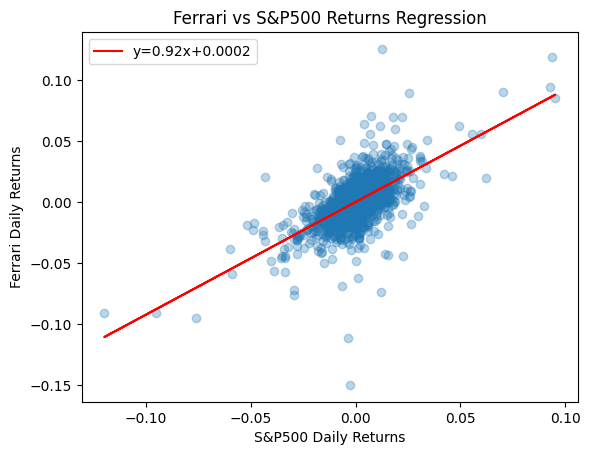

In [4]:
#SECTION 3: LINEAR REGRESSION
x = d_returns["^GSPC"]
y = d_returns["RACE"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Beta (slope): {slope:.4f}")
print(f"Alpha (intercept): {intercept:.6f}")
print(f"R-squared: {r_value**2:.4f}")
plt.scatter(d_returns["^GSPC"], d_returns["RACE"], alpha=0.3)
plt.plot(d_returns["^GSPC"], slope * d_returns["^GSPC"] + intercept, color="red", label=f"y={slope:.2f}x+{intercept:.4f}")
plt.xlabel("S&P500 Daily Returns")
plt.ylabel("Ferrari Daily Returns")
plt.title("Ferrari vs S&P500 Returns Regression")
plt.legend()
plt.show()


LINEAR REGRESSION ANALYSIS:

the slope - or beta - of the regression line is 0.9249, this indicates that ferrari moves roughly 0.92% for every 1% that the market moves
since it is under a 1% value this means that Ferrari stock is less volative than S&P 500.
this is due to the fact that Ferrari's clients are generally not affected by market shifts (opposed clients of some S&P 500 companies)

The y-intercept - or alpha - of the regression line is 0.000198. This means that 0.0198% of Ferrari's daily profits are independent of general market trends
Over the course of the year this small percentage ends up compounding to a net of 0.02 x 252 ~= 5% of extra annual returns

The R sqaured value is 0.4006 which indicates that only 40% of ferrari's daily movements are dictated by the market, the other 60 percent is determined by specific ferrari factors
From this value we can conclude that Ferrari behaves independently from the market

GRAPH ANALYSIS:

We notice by the graph that the slope results to be 0.92, and the intercept is closeby 0. Therefore we can conclude that the graph supports our linear regression analysis
Also we notice that there is a concentration of dots in the middle, which is normal given that on a daily basis stocks usually have returns close to zero
However we also notice dots that stand further from the center, which means that Ferrari is not totally dependent by the market.
We already found this with the R-sqaured value being 0.4 which confirms a moderate degree of dependence.